# All Imports
----------------

In [ ]:
import numpy as np

# pandas
from pandas.plotting import lag_plot
import pandas     as pd
import geopandas  as gpd

# graphics
import seaborn            as sns
import matplotlib.pyplot  as plt
import plotly.express     as px
import matplotlib.pyplot  as plt
from matplotlib.ticker import ScalarFormatter

# scikit
from sklearn.preprocessing          import MinMaxScaler
from sklearn.metrics                import r2_score, mean_absolute_error as mae, mean_squared_error as mse
from sklearn.ensemble               import IsolationForest

# SM
from statsmodels.tsa.stattools      import acf, pacf
from statsmodels.graphics.tsaplots  import plot_acf, plot_pacf
from statsmodels.tsa.stattools      import adfuller
from statsmodels.tsa.arima.model    import ARIMA

# R compatibility
import rpy2.robjects          as robjects
import rpy2.robjects.packages as rpackages
from rpy2.robjects.packages import importr
from rpy2.robjects          import numpy2ri, pandas2ri

# Dataset Loading
-----------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Custom Functions
-------------------

In [ ]:
def plot_over_year_period(dataref: pd.DataFrame, country: str, from_year: int, to_year: int, xtitle: str, ytitle: str, maintitle: str, normalize: bool = False):

  y = pd.DataFrame(dataref[((dataref.Year >= from_year) & (dataref.Year <= to_year)) & (dataref.Entity == country)])

  if normalize:
    minmax = MinMaxScaler()
    norm_y = minmax.fit_transform(y['all years'].to_numpy().reshape(-1, 1))
    y['all years'] = minmax.fit_transform(norm_y)

  sns.lineplot(data=y, x='Year',
               y='all years',
               label=country,
               marker='o',
              markersize=4,
              markevery=1,
              linewidth=1.5,
              palette='viridis')
  plt.xlabel(xtitle)
  plt.ylabel(ytitle)

  plt.legend(
        title="Data type",
        loc='best',
        frameon=True,
        shadow=True,
        fontsize=8
    )

  if normalize:
    country = 'various countries'
  plt.tight_layout()
  plt.title(maintitle)

In [ ]:
def multiplot(dataref: pd.DataFrame, rows: int, cols: int, countries: np.array, from_year: int, to_year: int, xtitle: str, ytitle: str, maintitle: str, with_subplot: bool = False, normalize=False):

  for i, country in enumerate(countries):
    if with_subplot:
      plt.subplot(rows, cols, i+1)

    plot_over_year_period(dataref, country, from_year, to_year, xtitle=xtitle, ytitle=ytitle, maintitle=maintitle, normalize=normalize)

In [ ]:
import warnings

def walk_forward_val(data, p, d, q, verbose=False):
    predictions = []
    actuals = []

    warnings.filterwarnings("ignore")

    # min required
    min_required = p + d + q + 1

    for i in range(min_required, len(data)):
        train_data = data.iloc[:i]
        test_value = data.iloc[i]

        try:
            model = ARIMA(train_data, order=(p, d, q))
            fitted_model = model.fit()

            forecast = fitted_model.forecast(steps=1)
            predictions.append(forecast.iloc[0])
            actuals.append(test_value)

        except Exception as e:
            if verbose:
                print(f"Skipping {data.index[i]}: {e}")
            continue

    return predictions, actuals


In [ ]:
def growth_percent_for(dataref: pd.DataFrame, country: str, from_year: int, to_year: int):
  return yugoslav_countries[yugoslav_countries['Entity'] == country]['all years'].pct_change().dropna() #drops first year

In [ ]:
def extract_eq(dataref: pd.DataFrame, attr: str, val: str):
  return dataref[dataref[attr] == val]

In [ ]:
def tsamodel_summary(y_pred, y_true):
  return f'R2: {r2_score(y_pred=y_pred, y_true=y_true):>15.3f}\nMSE: {mse(y_pred=y_pred, y_true=y_true):>15}\nMAE: {mae(y_pred=y_pred, y_true=y_true):>15}'

# 1. Data Fetching, Filtering and High Level Visualizations
------------------------------------------------------------

In [ ]:
all_countries_data = pd.read_csv('/content/drive/MyDrive/population.xls')

In [ ]:
all_countries_data
search_for = np.array(['North Macedonia', 'Serbia', 'Croatia', 'Montenegro', 'Bosnia and Herzegovina', 'Slovenia'])

In [ ]:
yugoslav_countries = all_countries_data[all_countries_data['Entity'].isin(search_for)]

In [ ]:
yugoslav_countries.Entity.unique() # ensure correctness of filtering

array(['Bosnia and Herzegovina', 'Croatia', 'Montenegro',
       'North Macedonia', 'Serbia', 'Slovenia'], dtype=object)

In [ ]:
min_year = yugoslav_countries.Year.min()
max_year = yugoslav_countries.Year.max()

## 1.1. Looking at the population of the former members over the years

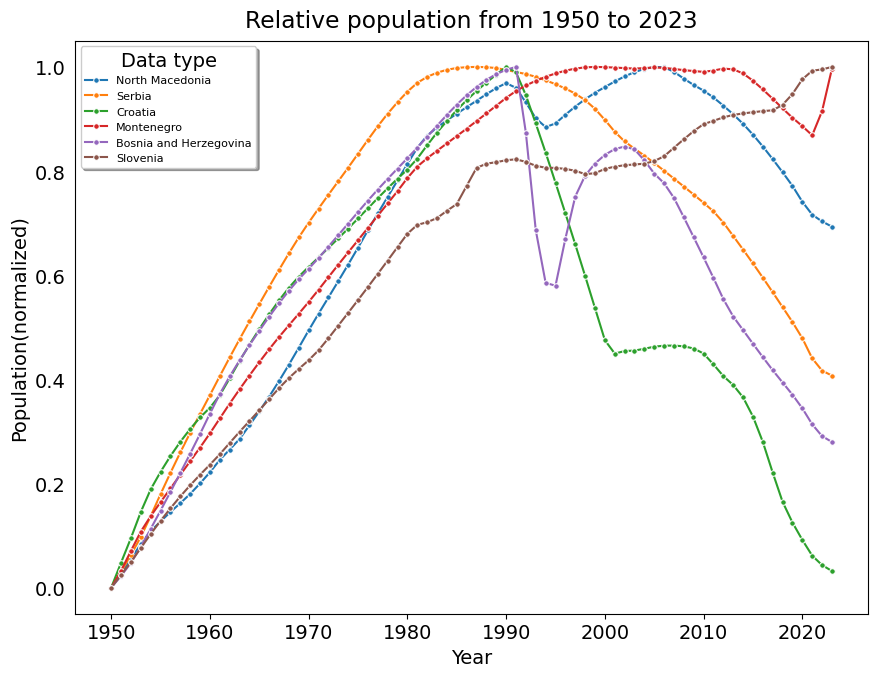

In [ ]:
plt.figure(figsize=(9,7))
rows = 2
cols = 3
multiplot(yugoslav_countries, rows, cols, search_for, min_year, yugoslav_countries.Year.max(), xtitle='Year', ytitle='Population(normalized)', maintitle='Relative population from 1950 to 2023', normalize=True)

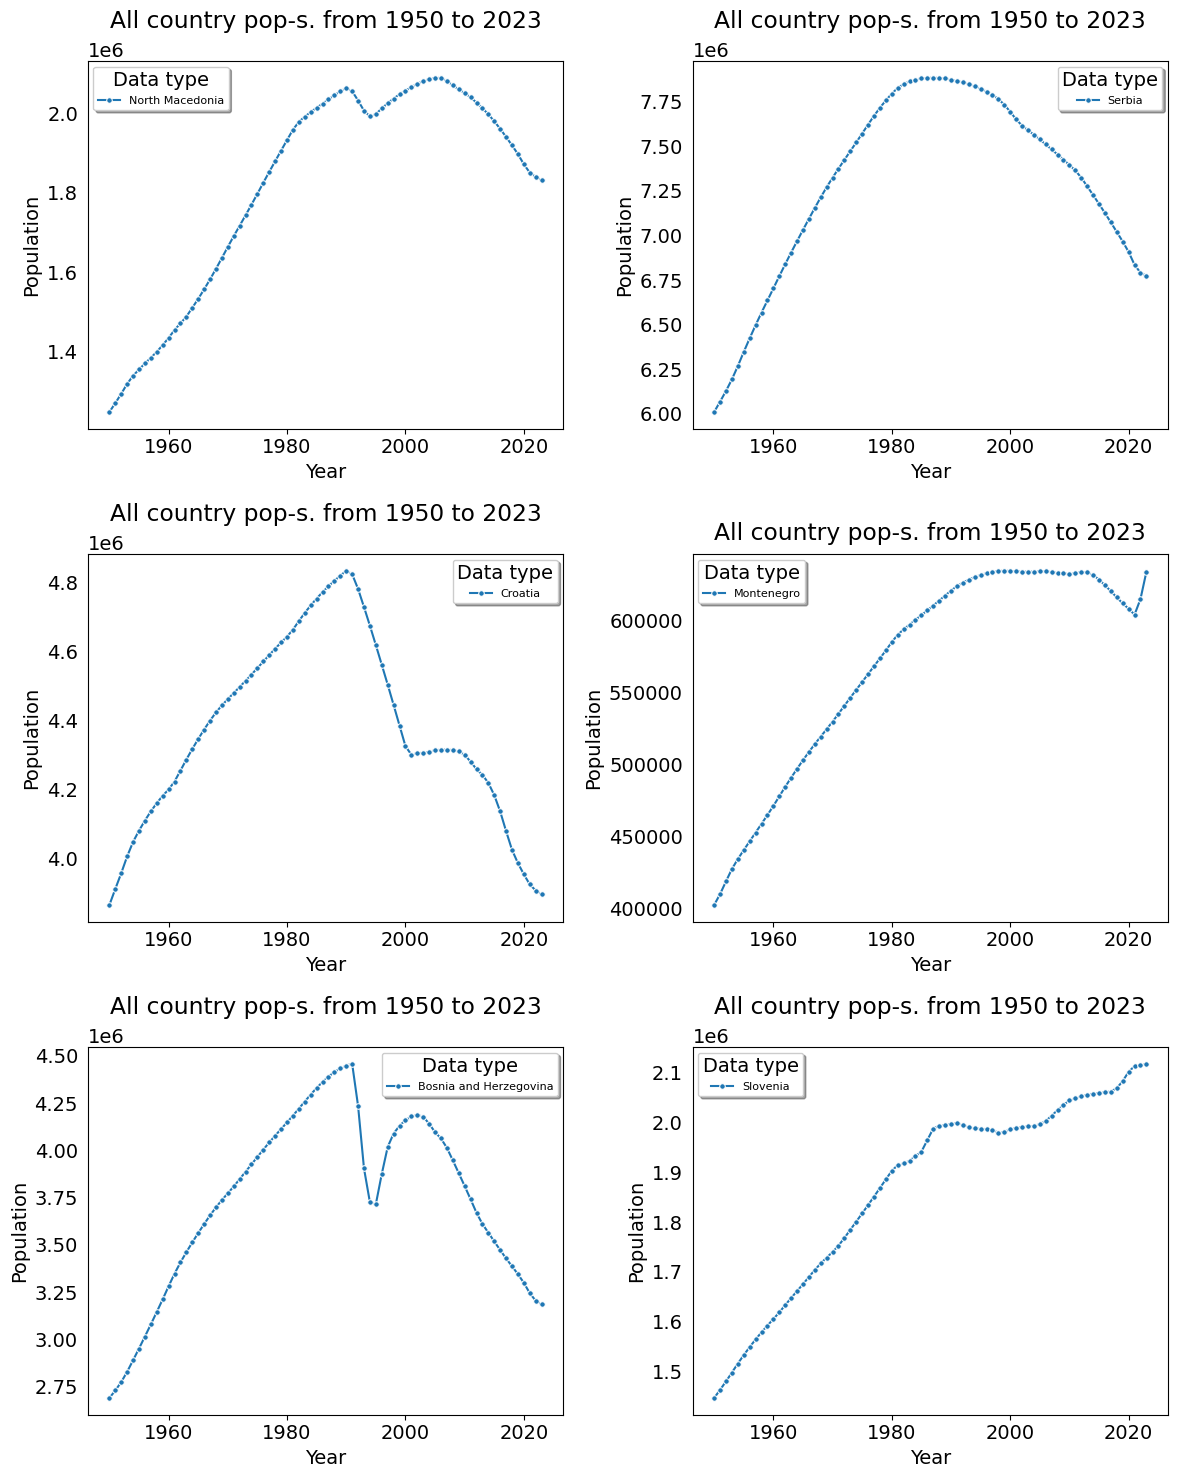

In [ ]:
plt.figure(figsize=(12, 15))
multiplot(yugoslav_countries, cols, rows, search_for, min_year, yugoslav_countries.Year.max(), xtitle='Year', ytitle='Population' ,maintitle='All country pop-s. from 1950 to 2023', with_subplot=True)

In [ ]:
iso_codes = {
    'Bosnia and Herzegovina': 'BIH',
    'Serbia': 'SRB',
    'Montenegro': 'MNE',
    'Croatia': 'HRV',
    'Slovenia': 'SVN',
    'North Macedonia': 'MKD'
}
yugoslav_countries['ISO3'] = yugoslav_countries['Entity'].map(iso_codes)

fig = px.choropleth(
    yugoslav_countries,
    locations='ISO3',
    color='all years',
    hover_name='Entity',
    animation_frame='Year',
    color_continuous_scale='algae',
    range_color=(yugoslav_countries['all years'].min(), yugoslav_countries['all years'].max()),
    scope='europe',
    title=f'Yugoslav Countries Data ({min_year} - {max_year})'
)

fig.update_geos(
    resolution=50,
    showcoastlines=True,
    showland=True,
    fitbounds="locations",
    landcolor="rgb(240, 240, 240)",
    lakecolor='rgb(80, 180, 255)',
    bgcolor='rgba(80, 200, 255, 0.4)',
)

fig.update_layout(
    width=1300,
    height=800,
    margin={"r":0,"t":60,"l":0,"b":0}
)

fig.show()

# 2. Autocorrelation, stationarity & independence on raw population
-------------------------------------------------------------------

In [ ]:
per_country_data = dict()

for c in search_for:
  per_country_data[c] = extract_eq(yugoslav_countries, 'Entity', c)


In [ ]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

## 2.1 Autocorrelation
----------------------

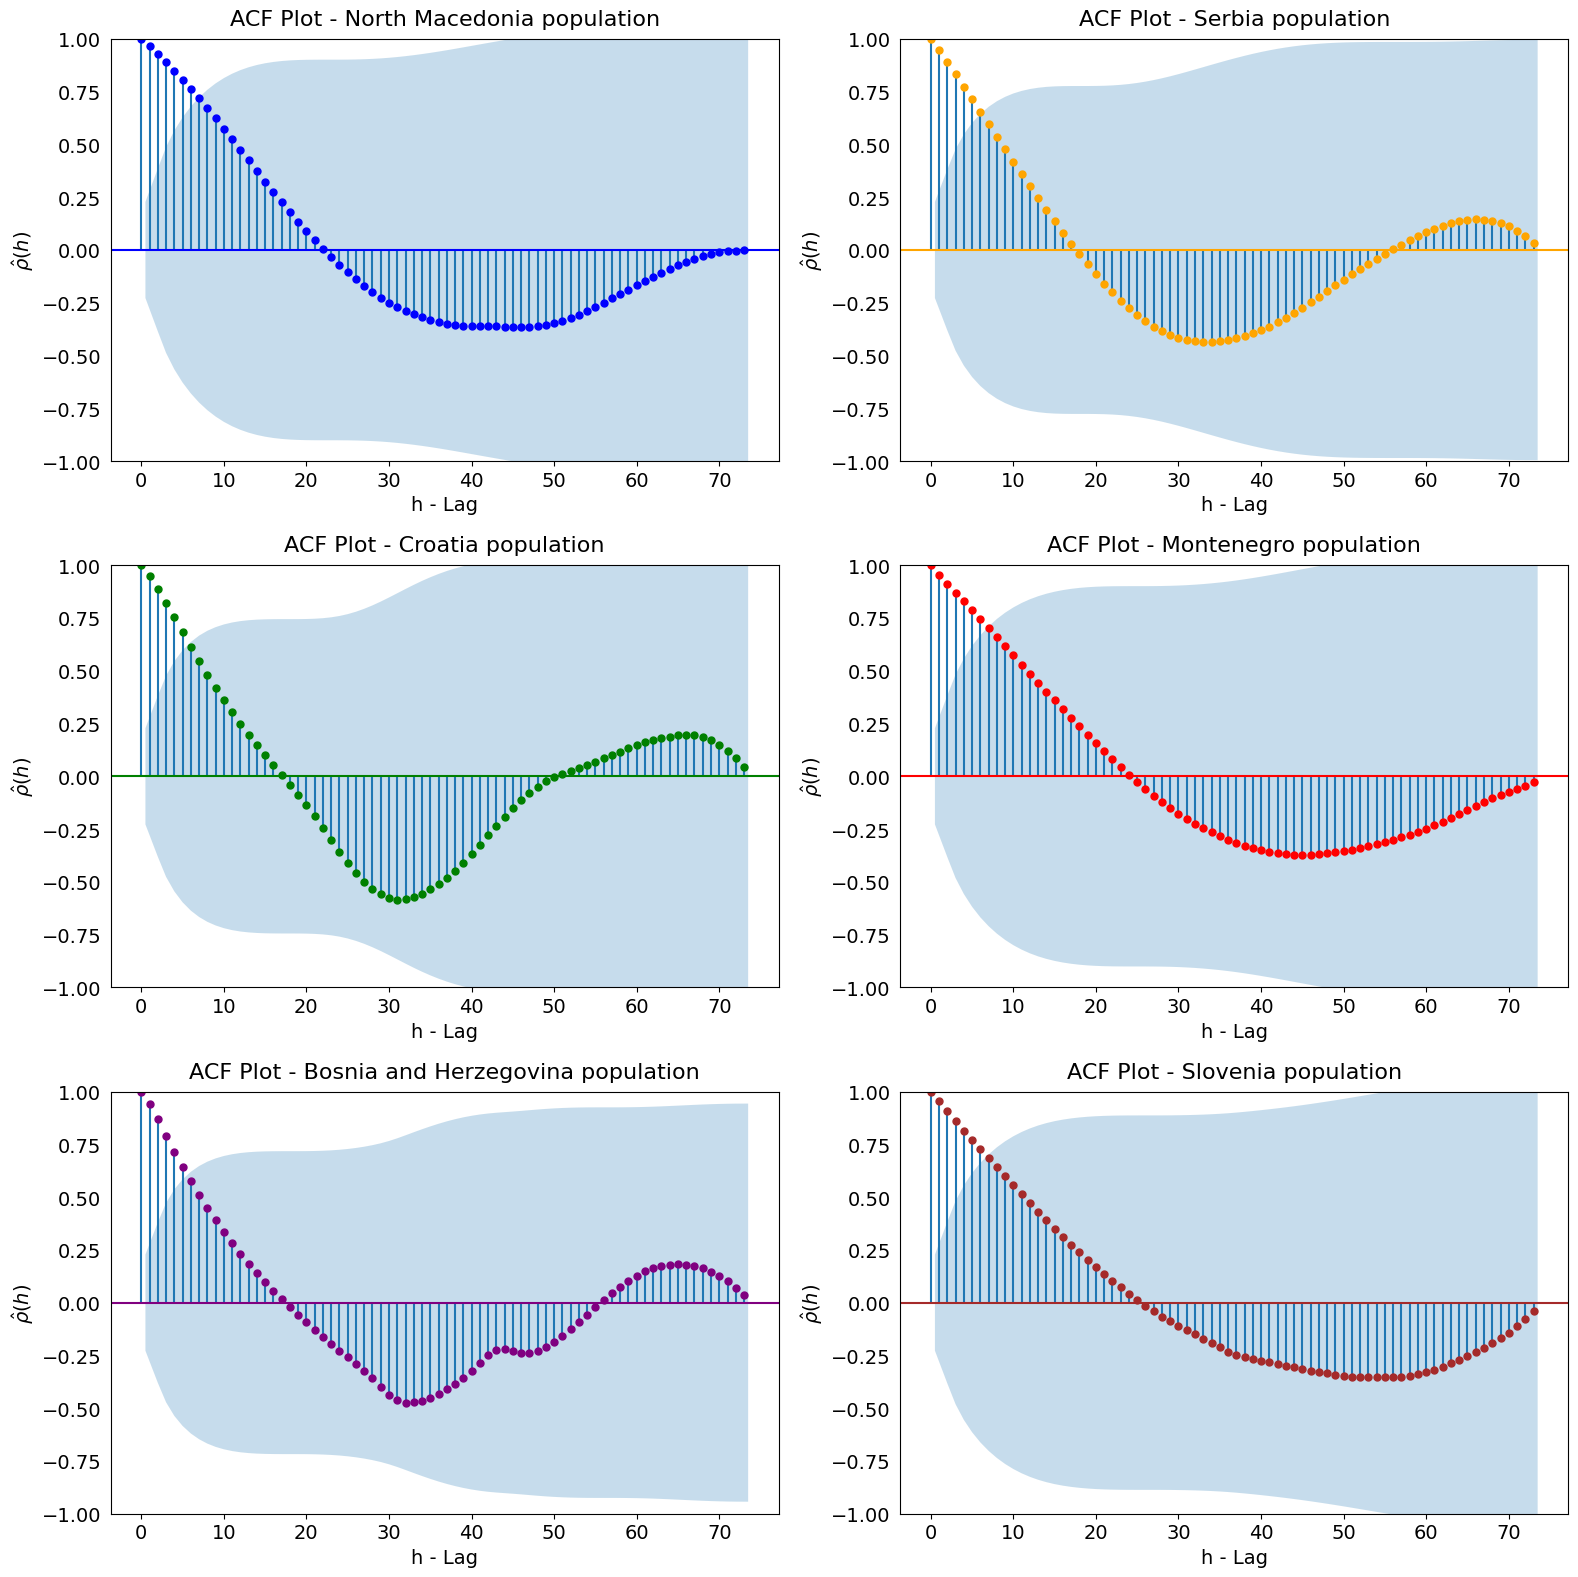

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=100)
axes = axes.flatten()

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i, country in enumerate(search_for):
    series = per_country_data[country]['all years']

    lags = len(per_country_data[c]['all years']) - 1

    plot_acf(series, lags=lags, ax=axes[i], color=colors[i], alpha=0.05)

    axes[i].set_title(f"ACF Plot - {country} population", fontsize=16)
    axes[i].set_xlabel("h - Lag", fontsize=14)
    axes[i].set_ylabel(r'$\hat{\rho}(h)$', fontsize=14)

plt.tight_layout()
plt.show()

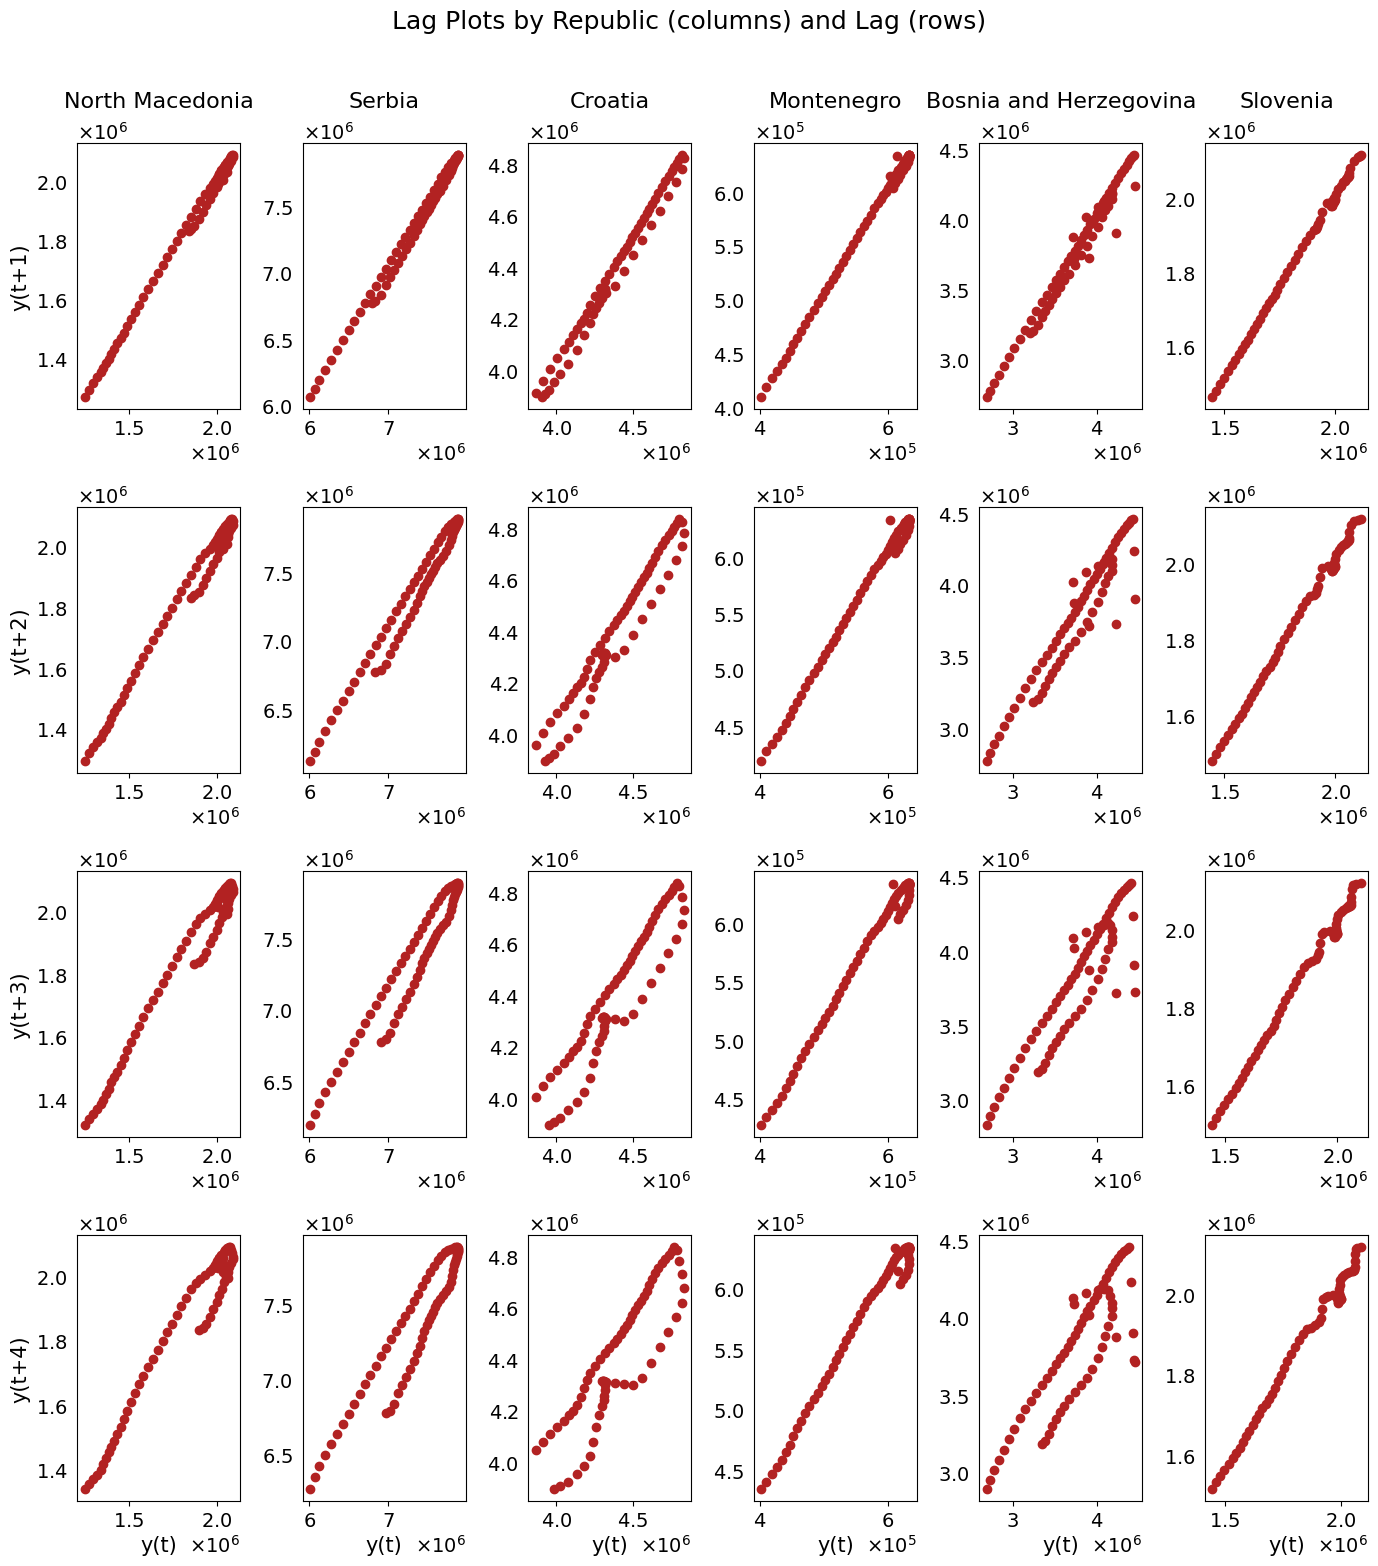

In [ ]:
plt.rcParams.update({'ytick.left': False, 'axes.titlepad': 10})

n_countries = len(search_for)
n_lags = 4
fig, axes = plt.subplots(n_lags, n_countries, figsize=(4 * n_countries - 10, 16), dpi=100)  # Removed sharex, sharey

for col, country in enumerate(search_for):
    for row in range(n_lags):
        ax = axes[row][col]
        lag_plot(per_country_data[country]['all years'], lag=row + 1, ax=ax, c='firebrick')

        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)

        # Top row: country names as titles
        if row == 0:
            ax.set_title(country, fontsize=16)

        # First column: y-axis labels showing lag
        if col == 0:
            ax.set_ylabel(f'y(t+{row + 1})', fontsize=15)
        else:
            ax.set_ylabel("")

        # Bottom row: x-axis label
        if row == n_lags - 1:
            ax.set_xlabel('y(t)', fontsize=15)
        else:
            ax.set_xlabel("")

fig.suptitle('Lag Plots by Republic (columns) and Lag (rows)', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


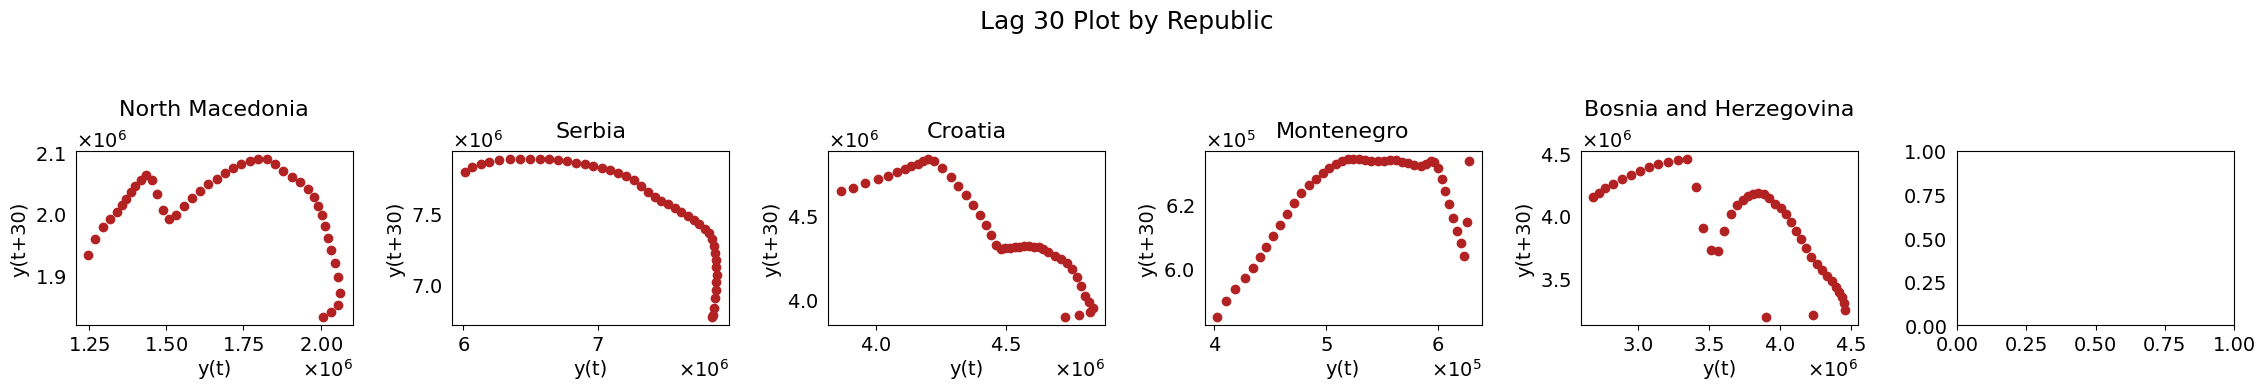

In [ ]:
lag_number = 30
n_countries = len(search_for)

fig, axes = plt.subplots(1, n_countries, figsize=(4 * n_countries - 1, 4), dpi=100)

if n_countries == 1:
    axes = [axes]

for col, country in enumerate(search_for[:5]):
    ax = axes[col]
    lag_plot(per_country_data[country]['all years'], lag=lag_number, ax=ax, c='firebrick')

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, 2))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    ax.set_title(country, fontsize=16)
    ax.set_xlabel(f'y(t)', fontsize=14)
    ax.set_ylabel(f'y(t+{lag_number})', fontsize=14)

fig.suptitle(f'Lag {lag_number} Plot by Republic', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## 2.2 Stationarity
-------------------

In [ ]:
for c in search_for:
  result = adfuller(per_country_data[c]['all years'])

  adf_p_val = result[1]

  print(f"Country: {c}")
  print(f"ADF Statistic: {result[0]}; p-value: {result[1]} -> {'stationary' if adf_p_val < 0.05 else 'non-stationary'}")
  print()

Country: North Macedonia
ADF Statistic: -1.7001598485634146; p-value: 0.431030119961724 -> non-stationary

Country: Serbia
ADF Statistic: -3.5003508671952277; p-value: 0.007978087619743949 -> stationary

Country: Croatia
ADF Statistic: -1.572399761796668; p-value: 0.49744147490778656 -> non-stationary

Country: Montenegro
ADF Statistic: -1.6924849681225735; p-value: 0.43498854763383776 -> non-stationary

Country: Bosnia and Herzegovina
ADF Statistic: -1.831844415101571; p-value: 0.36477031922236525 -> non-stationary

Country: Slovenia
ADF Statistic: -1.7653185145008865; p-value: 0.3978108822816162 -> non-stationary



## 2.3 ARIMA Forecasting
------------------------

In [ ]:
slovenia_pop = per_country_data['Slovenia']['all years']
slovenia_pop.index = pd.PeriodIndex(per_country_data['Slovenia'].Year, freq='Y')

In [ ]:
p, d, q = 7, 1, 2

In [ ]:
model = ARIMA(slovenia_pop, order=(p, d, q))
model.measurement_error = True

In [ ]:
fit_model = model.fit()

In [ ]:
points_pred, points_true = walk_forward_val(slovenia_pop, p, d, q)

In [ ]:
n = len(points_pred)

In [ ]:
offset_safe = p + d + q + 1 + 1950

df = pd.DataFrame({
    'Year': list(range(offset_safe, 2023)) + list(range(offset_safe, 2023)),
    'Entity': ['Predicted'] * n + ['Actual'] * n,
    'all years': points_pred + points_true
})

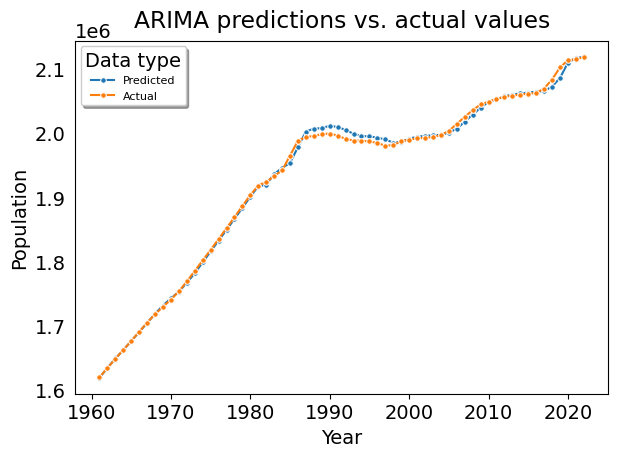

In [ ]:
multiplot(df, 1, 2, ['Predicted', 'Actual'], 1950 + p + d + q, 2023, xtitle='Year', ytitle='Population', maintitle='ARIMA predictions vs. actual values', normalize=False)

In [ ]:
print(tsamodel_summary(y_true=points_true, y_pred=points_pred))

R2:           0.998
MSE: 36200352.637975834
MAE: 4366.48279539178


In [ ]:
forecasted_till_2033 = fit_model.forecast(steps=10)

In [ ]:
df = pd.DataFrame({
    'Year': list(range(2023, 2033)),
    'Entity': ['Forecasted population'] * 10,
    'all years': forecasted_till_2033.tolist()
})

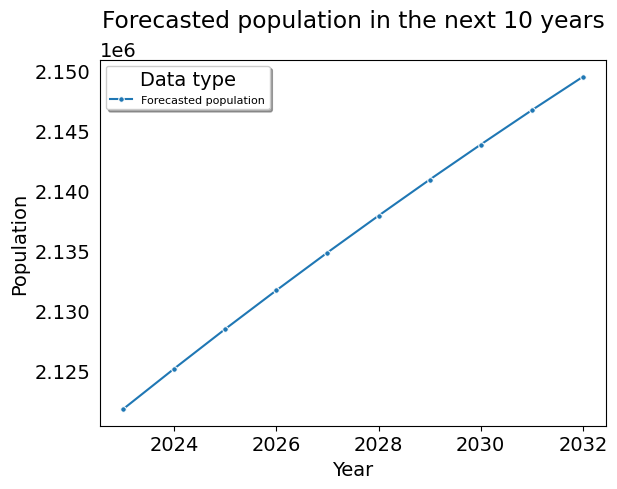

In [ ]:
multiplot(df, 1, 1, ['Forecasted population'], 2023, 2033, xtitle='Year', ytitle='Population', maintitle='Forecasted population in the next 10 years', normalize=False)

# 3. Annual Growth Rates
------------------------

In [ ]:
growth_rate_distributions = dict()
growth_rate_series = dict()
for c in search_for:
    growth = growth_percent_for(yugoslav_countries, c, min_year, max_year)
    growth_rate_distributions[c] = growth
    growth_rate_series[c] = pd.DataFrame({
        "Growth": growth,
        'Year': list(range(min_year, max_year))
    })

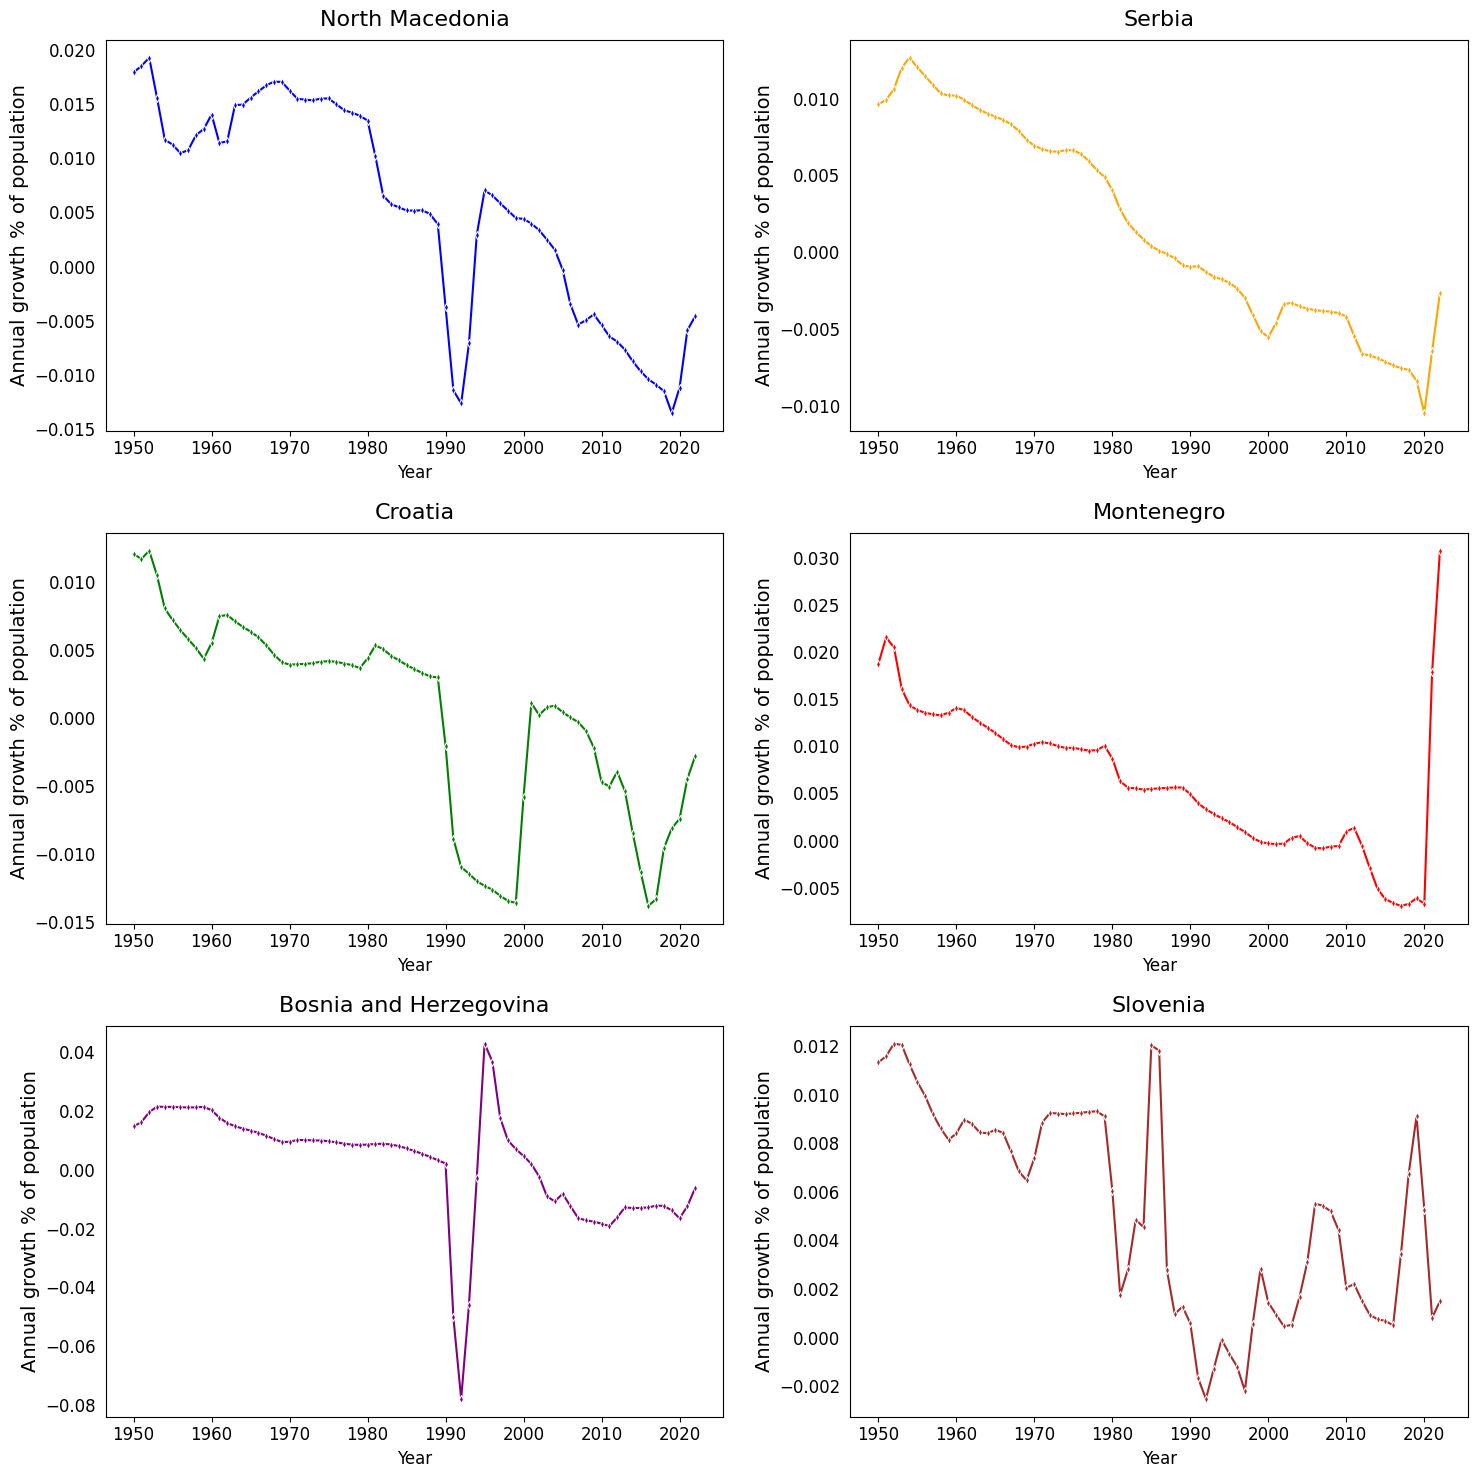

In [ ]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

plt.figure(figsize=(15, 15))
for i, c in enumerate(search_for):
    plt.subplot(3, 2, i+1)
    sns.lineplot(data=growth_rate_series[c], x='Year',
                 y='Growth',
                 marker='d',
                 markersize=4,
                 markevery=1,
                 linewidth=1.5,
                 color=colors[i])
    plt.title(f'{c}', fontsize=16)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Annual growth % of population", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


## 3.1. Autocorrelation
---------------------------------------------

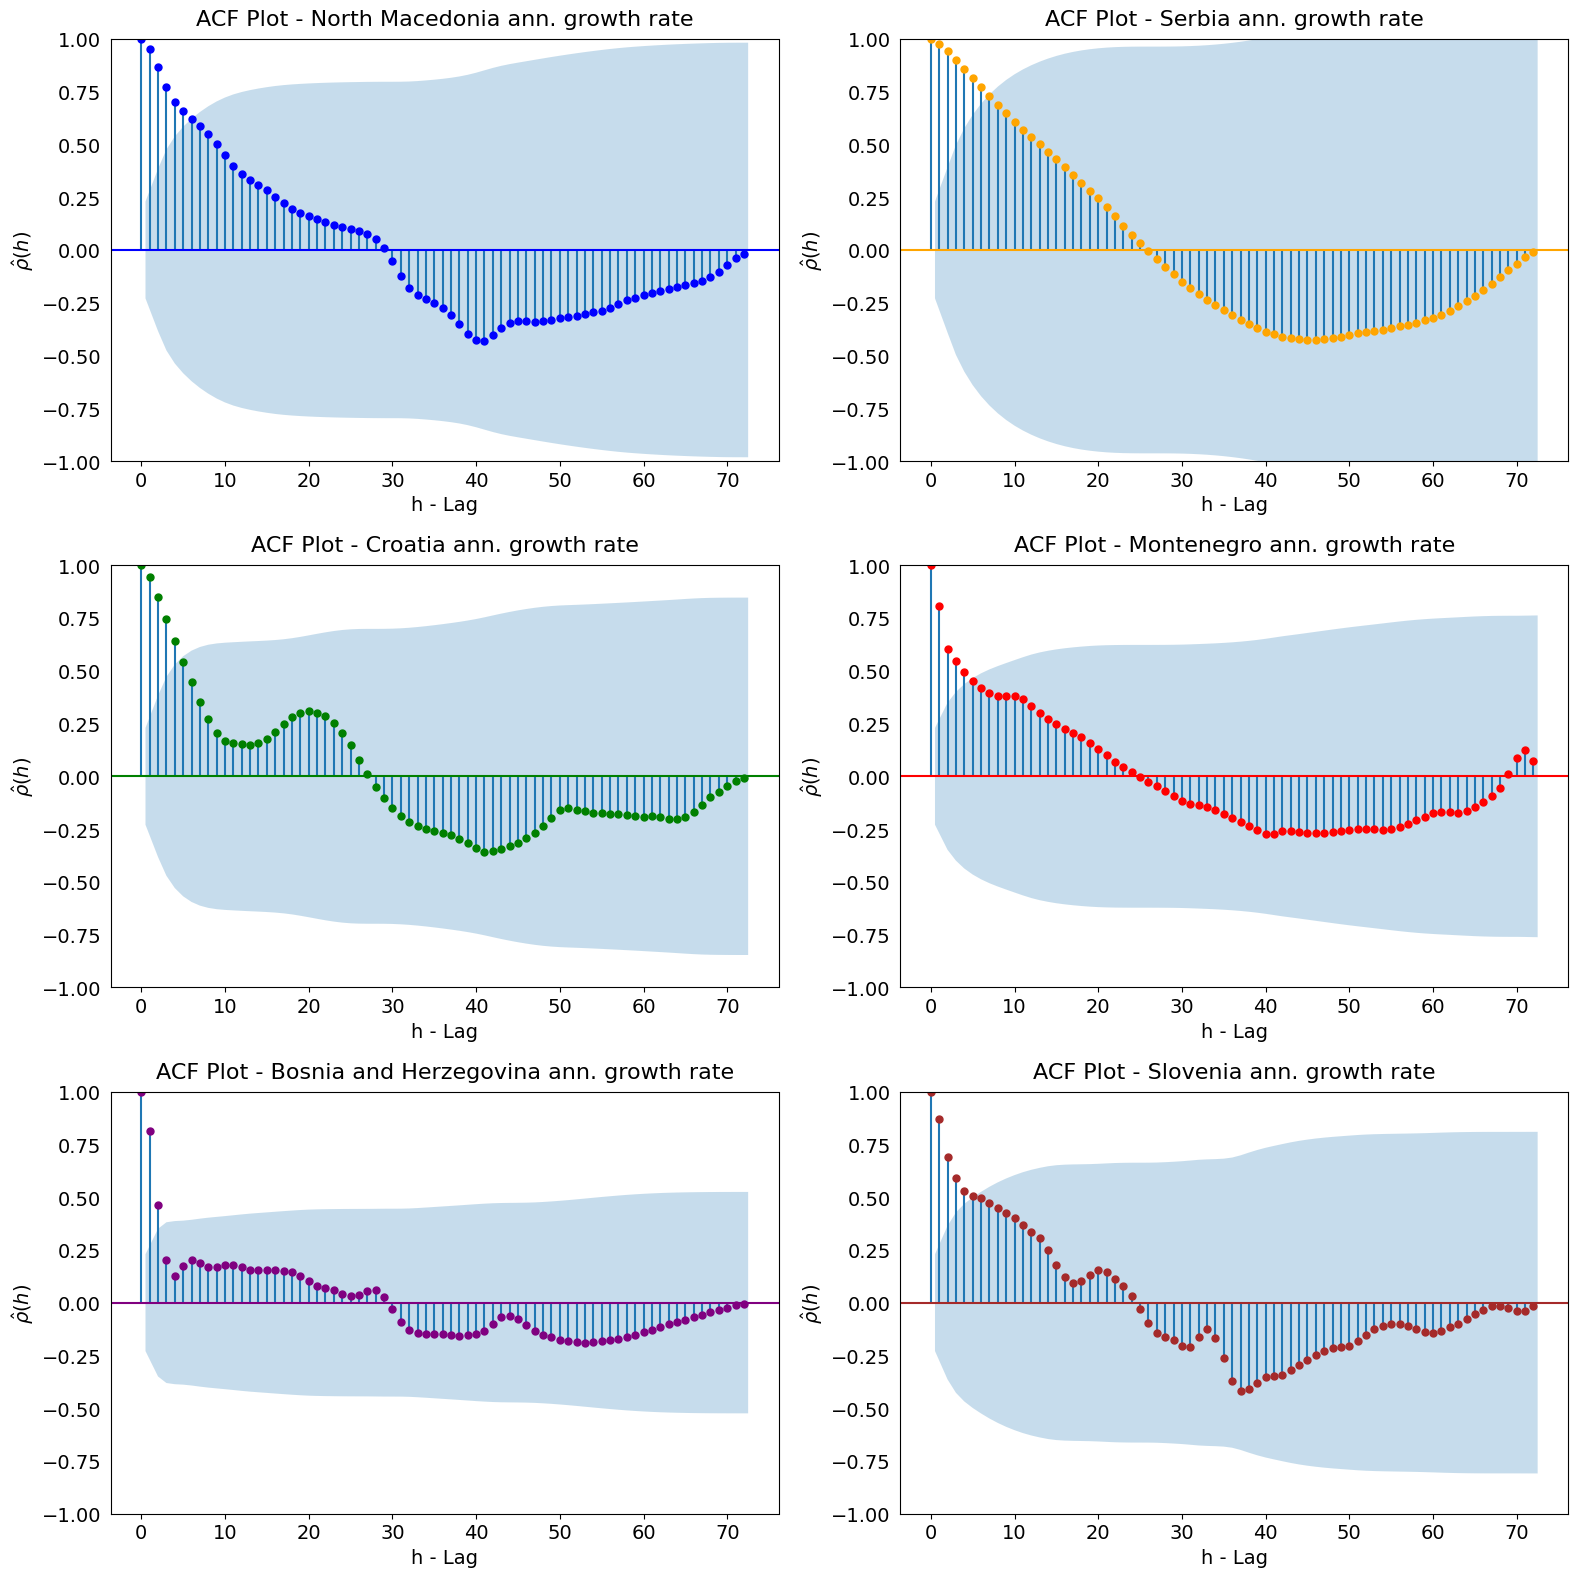

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=100)
axes = axes.flatten()

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i, country in enumerate(search_for):
    series = growth_rate_distributions[country]

    lags = len(growth_rate_distributions[c]) - 1

    plot_acf(series, lags=lags, ax=axes[i], color=colors[i], alpha=0.05)

    axes[i].set_title(f"ACF Plot - {country} ann. growth rate", fontsize=16)
    axes[i].set_xlabel("h - Lag", fontsize=14)
    axes[i].set_ylabel(r'$\hat{\rho}(h)$', fontsize=14)

plt.tight_layout()
plt.show()

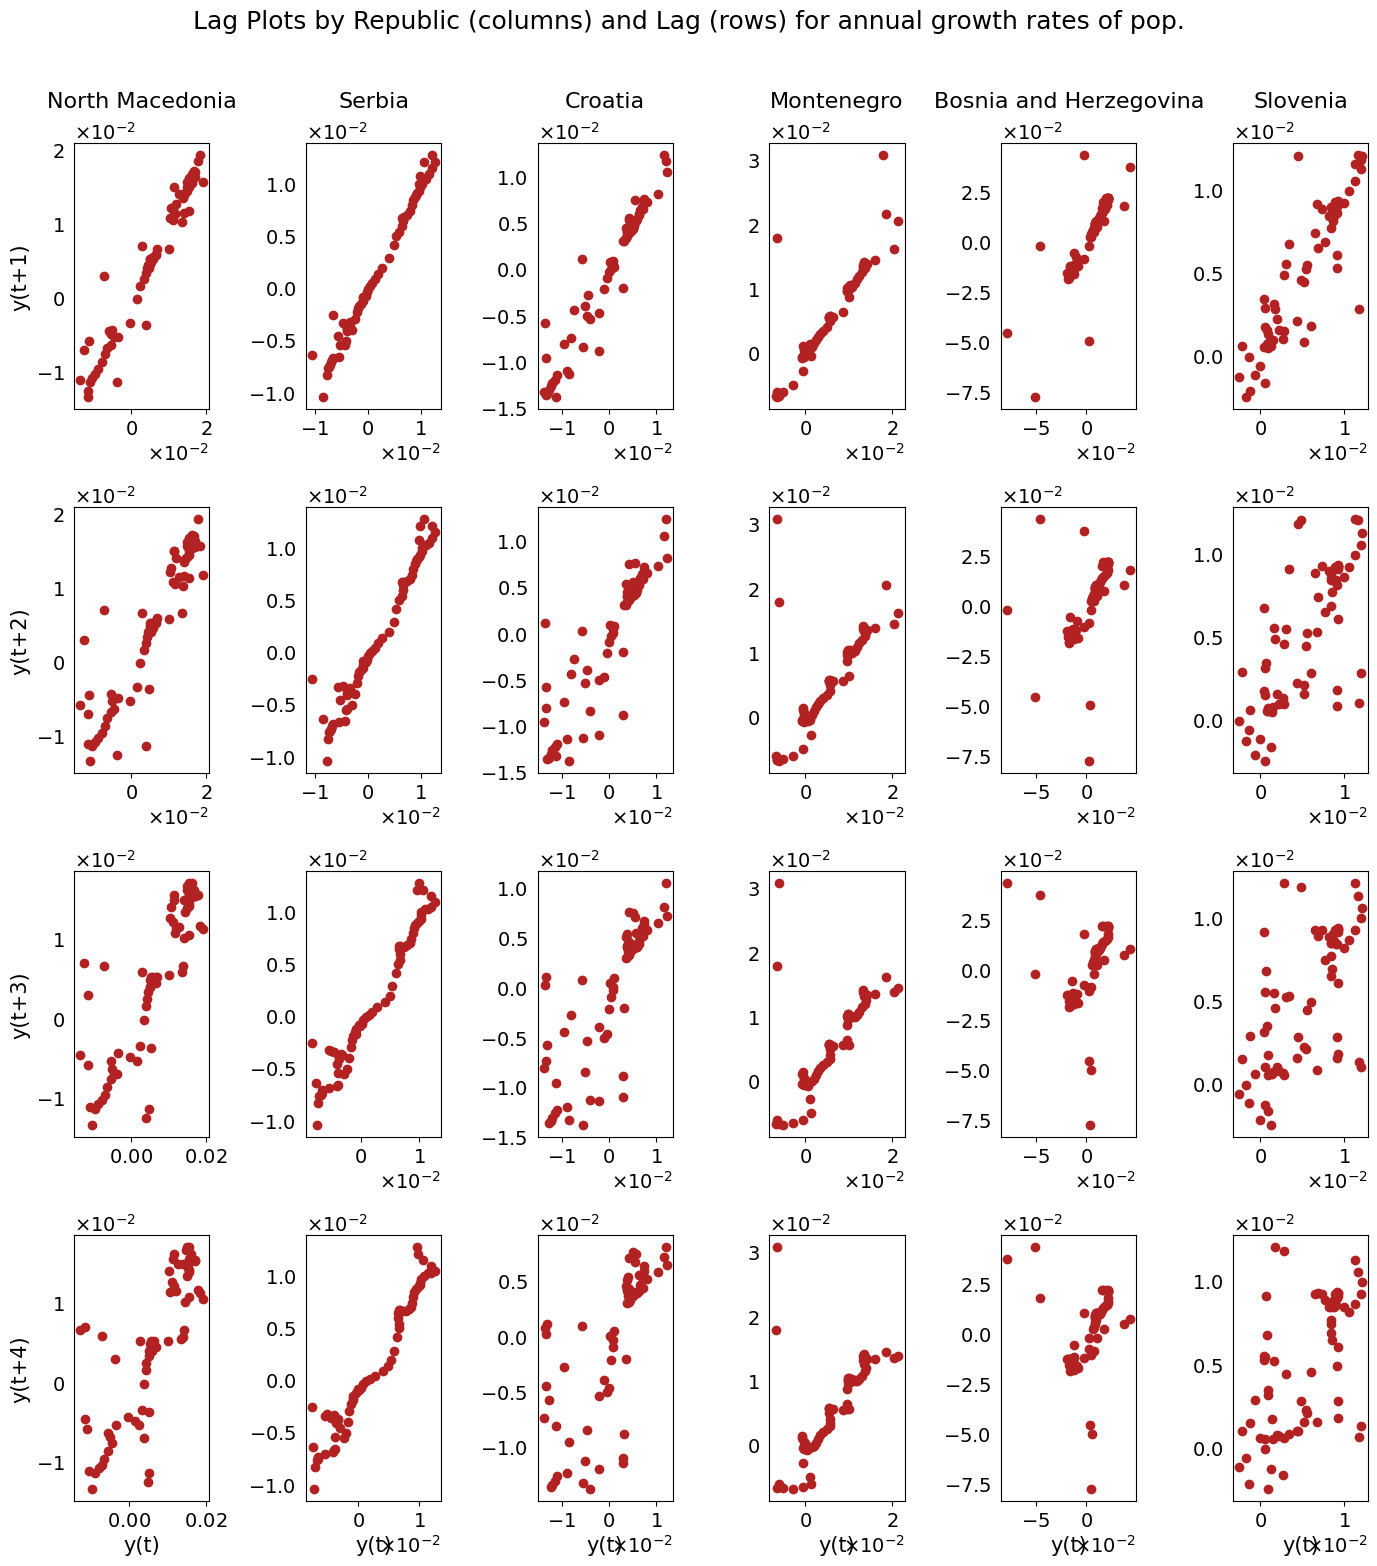

In [ ]:
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({'ytick.left': False, 'axes.titlepad': 10})

n_countries = len(search_for)
n_lags = 4
fig, axes = plt.subplots(n_lags, n_countries, figsize=(4 * n_countries - 10, 16), dpi=100)

for col, country in enumerate(search_for):
    for row in range(n_lags):
        ax = axes[row][col]
        lag_plot(growth_rate_distributions[country], lag=row + 1, ax=ax, c='firebrick')

        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))
        ax.xaxis.set_major_formatter(formatter)
        ax.yaxis.set_major_formatter(formatter)

        # highest row - country names (titles to the columns)
        if row == 0:
            ax.set_title(country, fontsize=16)

        # most left column - labels showing the lag number
        if col == 0:
            ax.set_ylabel(f'y(t+{row + 1})', fontsize=15)
        else:
            ax.set_ylabel("")


        if row == n_lags - 1:
            ax.set_xlabel('y(t)', fontsize=15)
        else:
            ax.set_xlabel("")

fig.suptitle('Lag Plots by Republic (columns) and Lag (rows) for annual growth rates of pop.', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 3.2 Stationarity
-------------------

In [ ]:
for c in search_for:
  result = adfuller(growth_rate_distributions[c])

  adf_p_val = result[1]

  print(f"Country: {c}")
  print(f"ADF Statistic: {result[0]}; p-value: {result[1]} -> {'stationary' if adf_p_val < 0.05 else 'non-stationary'}")
  print()

Country: North Macedonia
ADF Statistic: -0.5723637293989098; p-value: 0.8771052186934323 -> non-stationary

Country: Serbia
ADF Statistic: -1.0284988924388496; p-value: 0.7427286127904027 -> non-stationary

Country: Croatia
ADF Statistic: -1.2986626306677231; p-value: 0.6297839394490521 -> non-stationary

Country: Montenegro
ADF Statistic: -1.9954713382004485; p-value: 0.2885622830330421 -> non-stationary

Country: Bosnia and Herzegovina
ADF Statistic: -2.7943811568018067; p-value: 0.05908087312707506 -> non-stationary

Country: Slovenia
ADF Statistic: -1.8408147803315347; p-value: 0.3603947047531188 -> non-stationary



## 3.3 ARIMA Forecasting & Predicting
---------------------------------

In [ ]:
croatia_rate = growth_rate_series['Slovenia']['Growth']
croatia_rate.index = pd.PeriodIndex(growth_rate_series['Slovenia'].Year, freq='Y')

In [ ]:
p, d, q = 4, 1, 3
model_rate = ARIMA(croatia_rate, order=(p, d, q))

In [ ]:
fit_model_rate = model_rate.fit()

In [ ]:
rates_pred, rates_actual = walk_forward_val(croatia_rate, p, d, q)

In [ ]:
print(tsamodel_summary(y_pred=rates_pred, y_true=rates_actual))

R2:           0.709
MSE: 4.439592057794755e-06
MAE: 0.00132119617365302


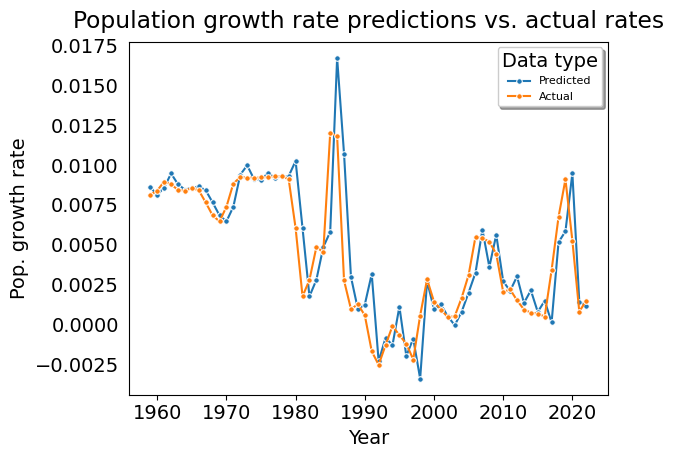

In [ ]:
offset_safe = p + d + q + 1 + 1950

df = pd.DataFrame({
    'Year': list(range(offset_safe, 2023)) + list(range(offset_safe, 2023)),
    'Entity': ['Predicted'] * len(rates_pred) + ['Actual'] * len(rates_actual),
    'all years': rates_pred + rates_actual
})

multiplot(df, 1, 1, ['Predicted', 'Actual'], offset_safe, 2023, xtitle='Year', ytitle='Pop. growth rate', maintitle='Population growth rate predictions vs. actual rates', normalize=False)

In [ ]:
rates_forecasted_till_2033 = fit_model_rate.forecast(steps=10)
rates_forecasted_till_2033

,predicted_mean
2023,0.001939
2024,0.002381
2025,0.003320
2026,0.003536
2027,0.003441
2028,0.003336
2029,0.003150
2030,0.003048
2031,0.003043
2032,0.003065


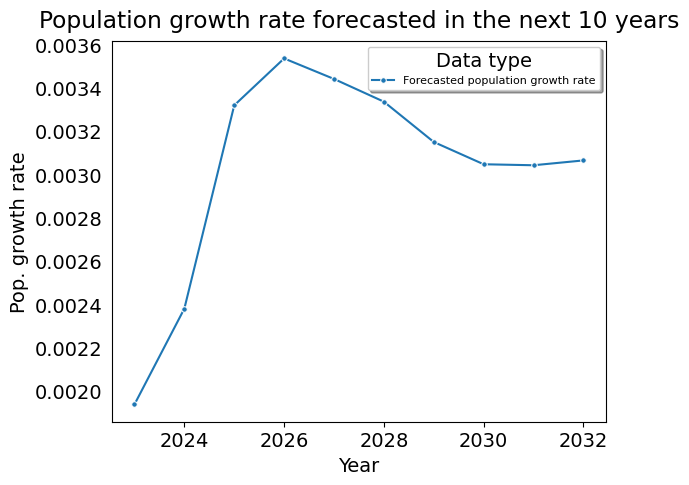

In [ ]:
df = pd.DataFrame({
    'Year': list(range(2023, 2033)),
    'Entity': ['Forecasted population growth rate'] * 10,
    'all years': rates_forecasted_till_2033.tolist()
})
multiplot(df, 1, 1, ['Forecasted population growth rate'], 2023, 2033, xtitle='Year', ytitle='Pop. growth rate', maintitle='Population growth rate forecasted in the next 10 years', normalize=False)


In [ ]:
forecasted_already_rates = forecasted_till_2033.pct_change().dropna()

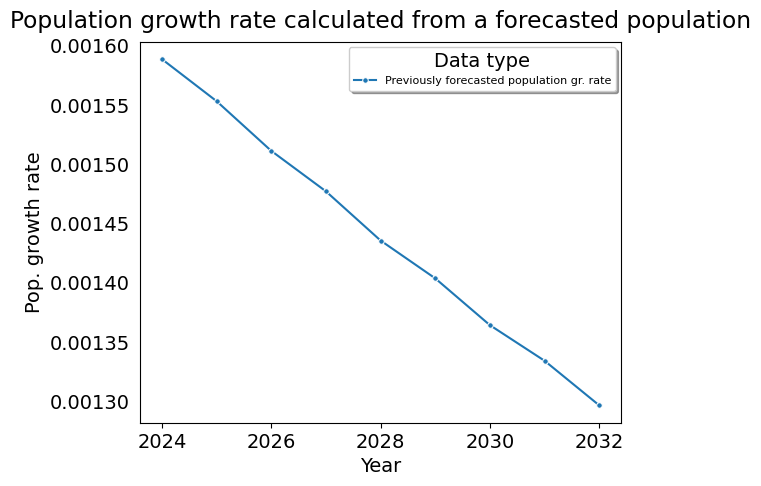

In [ ]:
df_new = pd.DataFrame({
    'Year': list(range(2024, 2033)),
    'Entity': ['Previously forecasted population gr. rate'] * 9,
    'all years': forecasted_already_rates.tolist()
})
multiplot(df_new, 1, 1, ['Previously forecasted population gr. rate'], 2023, 2033, xtitle='Year', ytitle='Pop. growth rate', maintitle='Population growth rate calculated from a forecasted population', normalize=False)


# 4. Regime Changes
-------------------

In [ ]:
numpy2ri.activate()

In [ ]:
utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)

if not rpackages.isinstalled("strucchange"):
    utils.install_packages("strucchange")

In [ ]:
strucchange = importr("strucchange")

In [ ]:
single_country = yugoslav_countries[yugoslav_countries.Entity == 'Bosnia and Herzegovina'].drop(columns=['Entity'])

In [ ]:
single_country

,Year,all years,ISO3
2146,1950,2690354,BIH
2147,1951,2730187,BIH
2148,1952,2774647,BIH
2149,1953,2829177,BIH
2150,1954,2890165,BIH
...,...,...,...
2215,2019,3345480,BIH
2216,2020,3299297,BIH
2217,2021,3244869,BIH
2218,2022,3204770,BIH


In [ ]:
breaks_per_country = dict()
supF_results = dict()
numpy2ri.activate()

for c in search_for:
	single_country = extract_eq(yugoslav_countries, 'Entity', c)
	max_breakpoints = 10
	h_val = len(single_country) // max_breakpoints

	# R interface calls
	robjects.globalenv["pop"] = single_country['all years'].to_numpy()
	robjects.r("time <- 1:length(pop)")
	robjects.r("data <- data.frame(pop=pop, time=time)")

	robjects.r("library(strucchange)")
	robjects.r(f"bp <- breakpoints(pop ~ 1, data=data, h={h_val})")

	robjects.r("test_result <- sctest(pop ~ 1, data=data, type='supF')")

	robjects.r("aic_values <- AIC(bp)")
	best_k = int(robjects.r("which.min(aic_values)")[0])

	robjects.r(f"final_bp <- breakpoints(pop ~ 1, data=data, breaks={best_k})")

	robjects.r("break_dates <- breakdates(final_bp)")
	breaks_per_country[c] = np.array(
			 single_country.Year.iloc[np.int64(np.array(robjects.r("break_dates")) * len(single_country))]
	)

	test_result = robjects.r("test_result")
	p_value = test_result.rx2('p.value')[0]
	statistic = test_result.rx2('statistic')[0]
	supF_results[c] = {'statistic': statistic, 'p_value': p_value}

In [ ]:
for breakk in breaks_per_country.keys():
  breaks = breaks_per_country[breakk]
  print(f'Country: {breakk}\nNum. breaks: {len(breaks)}\nYears: {breaks}\np-val of supF: {supF_results[c]}\n')

Country: North Macedonia
Num. breaks: 4
Years: [1961 1971 1983 2013]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}

Country: Serbia
Num. breaks: 4
Years: [1961 1973 2001 2013]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}

Country: Croatia
Num. breaks: 5
Years: [1961 1971 1983 1997 2013]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}

Country: Montenegro
Num. breaks: 3
Years: [1961 1971 1984]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}

Country: Bosnia and Herzegovina
Num. breaks: 5
Years: [1961 1971 1983 1993 2012]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}

Country: Slovenia
Num. breaks: 4
Years: [1961 1973 1984 2009]
p-val of supF: {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}



In [ ]:
print(supF_results)

{np.str_('North Macedonia'): {'statistic': np.float64(358.4231909872913), 'p_value': np.float64(0.0)}, np.str_('Serbia'): {'statistic': np.float64(116.6825818107328), 'p_value': np.float64(0.0)}, np.str_('Croatia'): {'statistic': np.float64(24.34576530773298), 'p_value': np.float64(2.7179909158909112e-05)}, np.str_('Montenegro'): {'statistic': np.float64(309.95847626541274), 'p_value': np.float64(0.0)}, np.str_('Bosnia and Herzegovina'): {'statistic': np.float64(75.51946810080912), 'p_value': np.float64(2.220446049250313e-16)}, np.str_('Slovenia'): {'statistic': np.float64(309.3689394276628), 'p_value': np.float64(0.0)}}


## 4.1 Bosnia dissection by break analysis
------------------------------------------

In [ ]:
bosnia_data = extract_eq(yugoslav_countries, 'Entity', 'Bosnia and Herzegovina')

In [ ]:
years_dissect = list(breaks_per_country['Bosnia and Herzegovina']) + [2023]

In [ ]:
dissection = dict()

In [ ]:
for i in range(len(years_dissect) - 1):
  lo, hi = years_dissect[i], years_dissect[i+1]
  dissection[f'{lo} - {hi}'] = bosnia_data[(bosnia_data.Year > lo) & (bosnia_data.Year <= hi)]

In [ ]:
len(dissection) # 4 regions

5

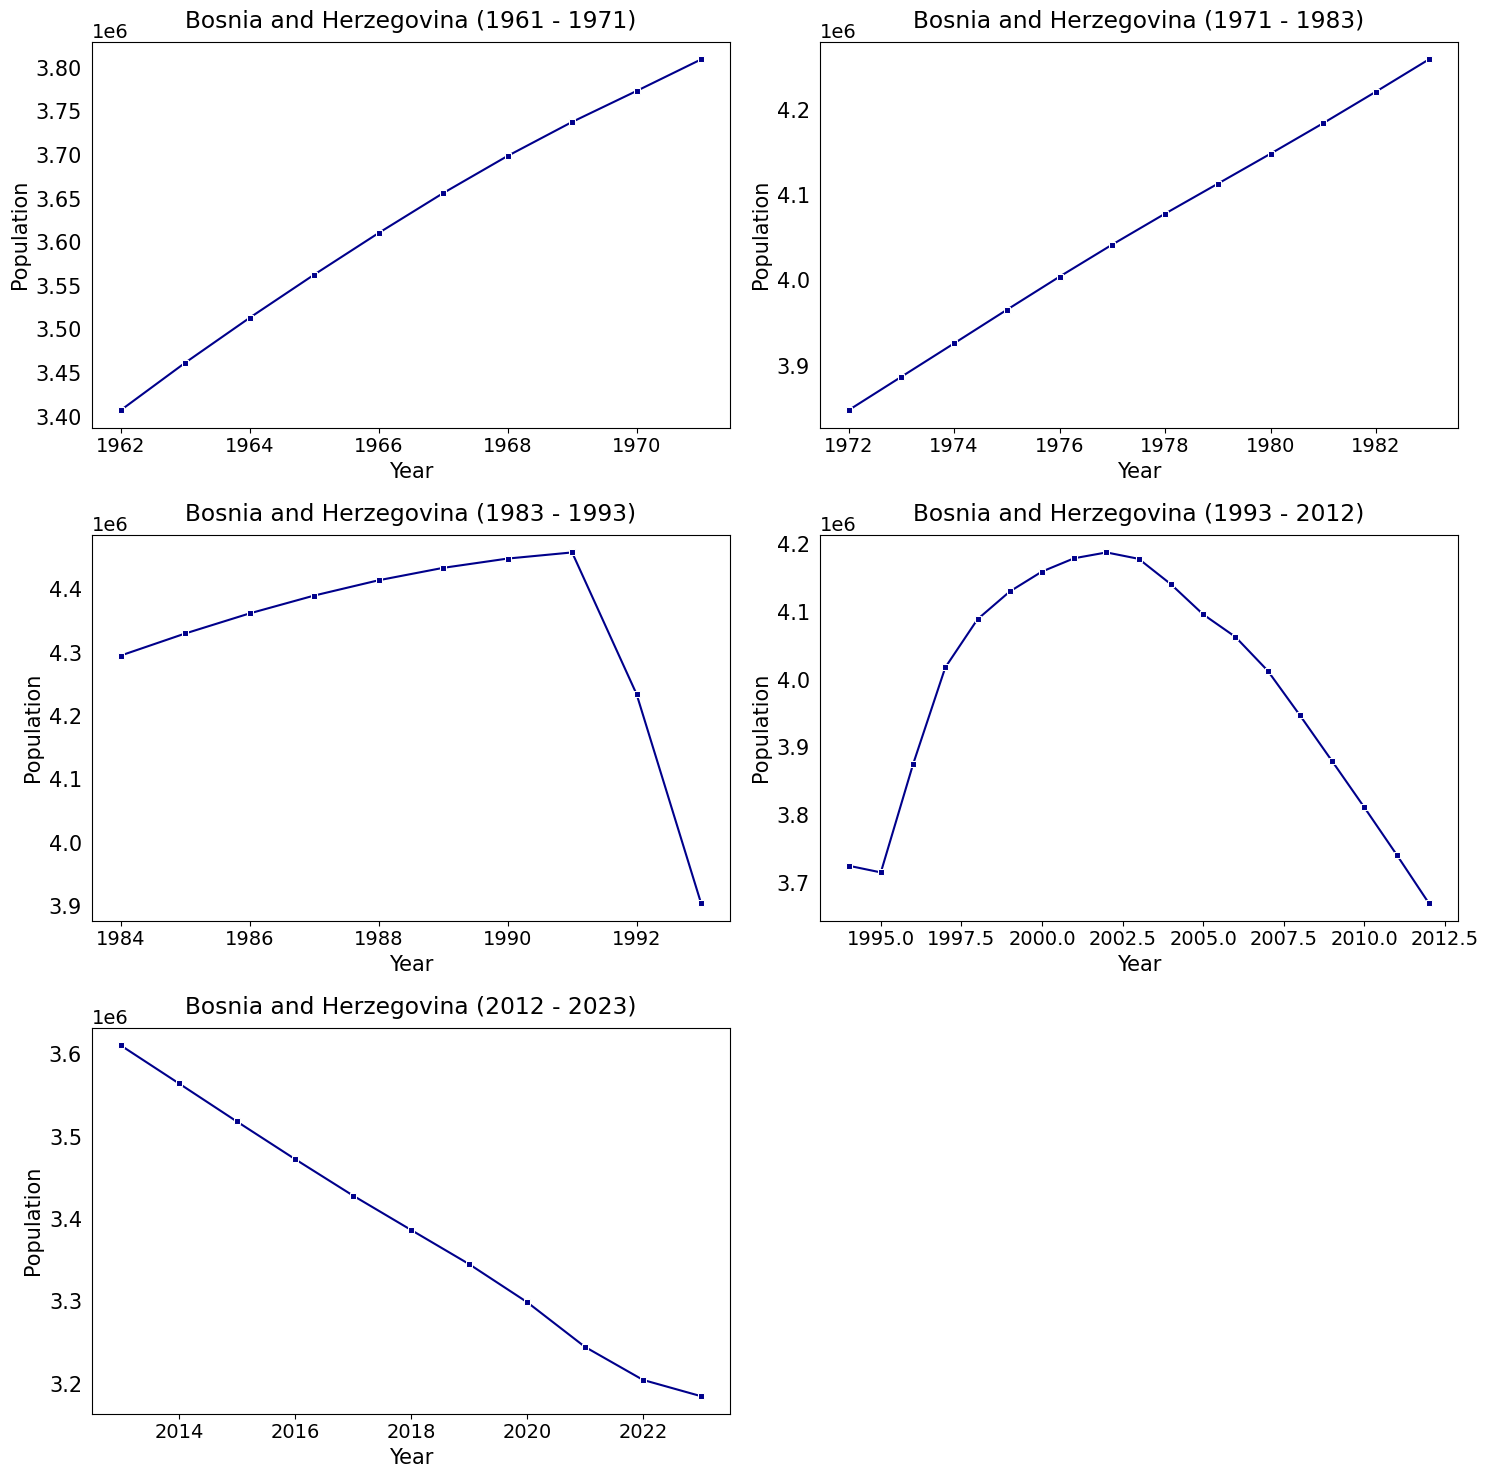

In [ ]:
plt.figure(figsize=(15, 15))
for i, region in enumerate(dissection.keys()):
    plt.subplot(3, 2, i+1, title=f'Bosnia and Herzegovina ({region})')
    sns.lineplot(data=dissection[region], x='Year',
                 y='all years',
                 marker='s',
                 markersize=4,
                 markevery=1,
                 linewidth=1.5,
                 color='darkblue')
    plt.xlabel("Year", fontsize=15)
    plt.ylabel("Population", fontsize=15)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()


# 5. General Anomaly Detection

## 5.1 Interpretation
---------------------

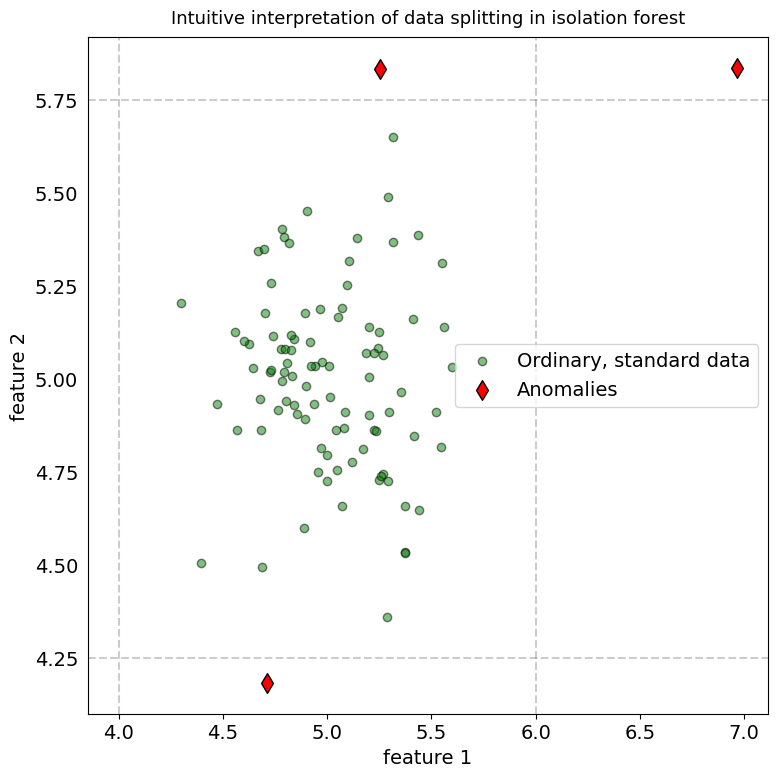

In [ ]:
np.random.seed(123)

cluster_x = np.random.normal(loc=5, scale=0.25, size=95)
cluster_y = np.random.normal(loc=5, scale=0.25, size=95)

outlier_x = np.random.uniform(4, 7, size=3)
outlier_y = np.random.uniform(4, 6, size=3)

plt.figure(figsize=(8, 8))
plt.scatter(cluster_x, cluster_y, label='Ordinary, standard data', alpha=0.5, edgecolor='black', color='green', marker='o')
plt.scatter(outlier_x, outlier_y, label='Anomalies', color='red', s=100, edgecolor='black', marker='d')

for cut in [4, 6]:
    plt.axvline(x=cut, linestyle='--', color='gray', alpha=0.4)

for cut in [5.75, 4.25]:
    plt.axhline(y=cut, linestyle='--', color='gray', alpha=0.4)


plt.title('Intuitive interpretation of data splitting in isolation forest', fontsize=13)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.tight_layout()
plt.show()


## 5.2 Training and detection

In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

results = {}

for c in search_for:
    pop_series = extract_eq(yugoslav_countries, 'Entity', c)['all years']
    values = pop_series.values

    X = values.reshape(-1, 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_forest.fit(X_scaled)
    preds = iso_forest.predict(X_scaled)

    anomalies = preds == -1
    anomalous_years = []

    for ind, anomaly in enumerate(anomalies):
      if anomaly:
        anomalous_years += [ind + 1950]

    print(f'Country: {c}\nYears as anomalies:{anomalous_years}\nPopulations:{pop_series.iloc[np.array(anomalous_years) - 1950].tolist()}')

    years = pop_series.index
    results[c] = {
        'years': years,
        'values': values,
        'anomalies': anomalies,
        'jitter': np.random.uniform(-0.1, 0.1, size=len(values))
    }


Country: North Macedonia
Years as anomalies:[1950, 1951, 1952, 1953]
Populations:[1248628, 1270990, 1294492, 1319425]
Country: Serbia
Years as anomalies:[1950, 1951, 1952, 1953]
Populations:[6009148, 6067002, 6127217, 6192368]
Country: Croatia
Years as anomalies:[1950, 1990, 2021, 2023]
Populations:[3864936, 4835027, 3924558, 3895973]
Country: Montenegro
Years as anomalies:[1950, 1951, 1952, 1953]
Populations:[402476, 410024, 418859, 427440]
Country: Bosnia and Herzegovina
Years as anomalies:[1950, 1951, 1952, 1991]
Populations:[2690354, 2730187, 2774647, 4458299]
Country: Slovenia
Years as anomalies:[1950, 1951, 2020, 2023]
Populations:[1446309, 1462680, 2102370, 2118353]


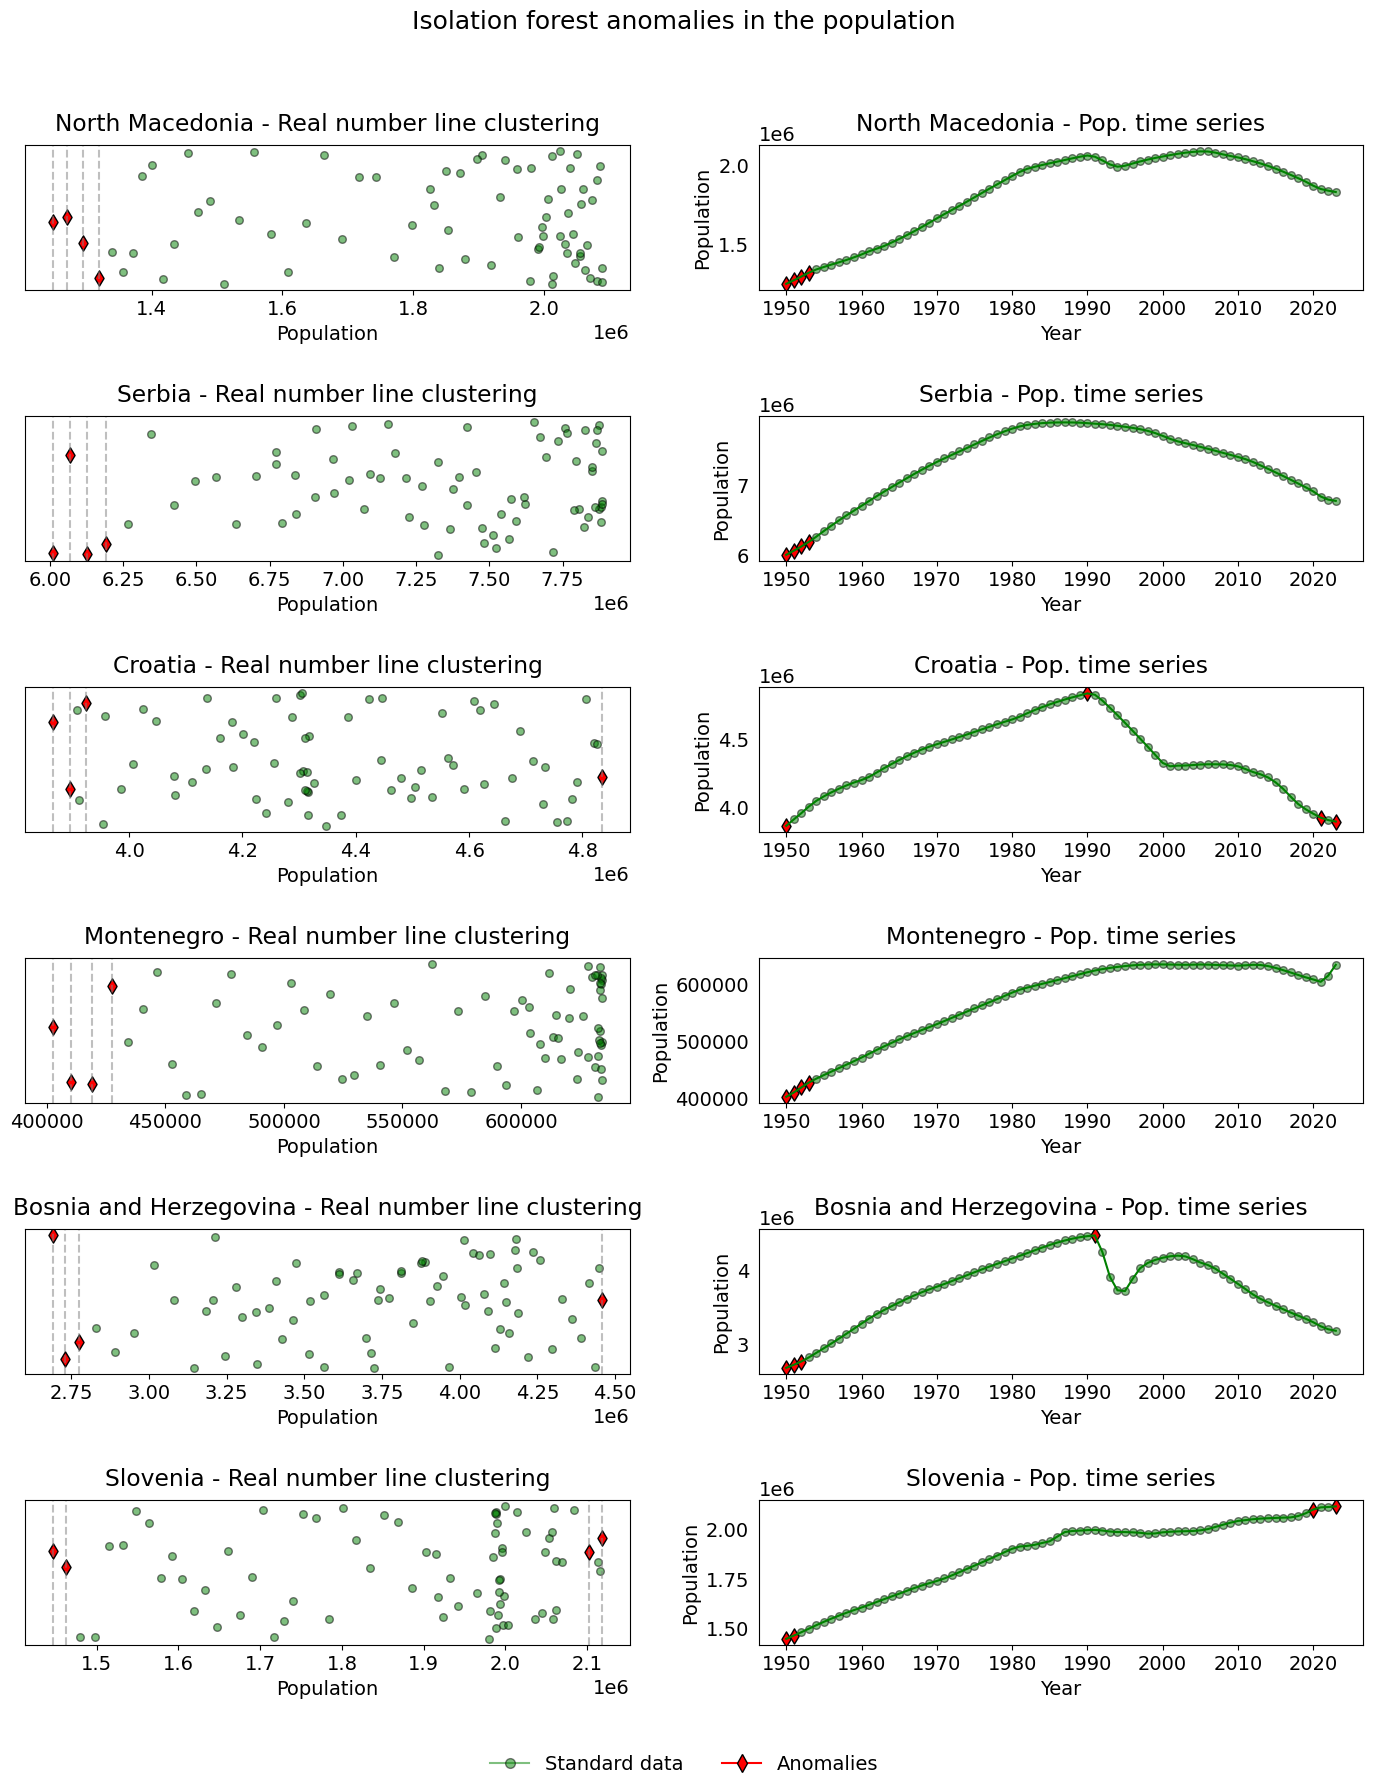

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

countries = list(results.keys())
fig, axs = plt.subplots(len(countries), 2, figsize=(14, 3 * len(countries)))
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.rcParams.update({'font.size': 14})

legend_elements = [
    Line2D([0], [0], marker='o', color='green', label='Standard data',
           markerfacecolor='green', markersize=7, alpha=0.5, markeredgecolor='black'),
    Line2D([0], [0], marker='d', color='red', label='Anomalies',
           markerfacecolor='red', markersize=9, markeredgecolor='black')
]

for i, c in enumerate(countries):
    years = extract_eq(yugoslav_countries, 'Entity', c)['Year']
    values = results[c]['values']
    anomalies = results[c]['anomalies']
    jitter = results[c]['jitter']

    axs[i, 0].scatter(
        values[~anomalies], jitter[~anomalies],
        alpha=0.5, edgecolor='black', color='green', marker='o', s=30
    )
    axs[i, 0].scatter(
        values[anomalies], jitter[anomalies],
        color='red', s=60, edgecolor='black', marker='d'
    )
    for val in values[anomalies]:
        axs[i, 0].axvline(x=val, linestyle='--', color='gray', alpha=0.5)

    axs[i, 0].set_yticks([])
    axs[i, 0].set_xlabel('Population')
    axs[i, 0].set_title(f'{c} - Real number line clustering')

    axs[i, 1].plot(years, values, color='green', label='Population')
    axs[i, 1].scatter(
        years[~anomalies], values[~anomalies],
        alpha=0.5, edgecolor='black', color='green', marker='o', s=30
    )
    axs[i, 1].scatter(
        years[anomalies], values[anomalies],
        color='red', s=60, edgecolor='black', marker='d'
    )
    axs[i, 1].set_xlabel('Year', fontsize=14)
    axs[i, 1].set_ylabel('Population', fontsize=14)
    axs[i, 1].set_title(f'{c} - Pop. time series')

fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Isolation forest anomalies in the population', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()
